<a href="https://colab.research.google.com/github/niruinso/Course_Work/blob/develop/src/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
np.random.seed(42)

## Предлагаю рассмотреть следующую разновидность модели - на основе метода опорных векторов. Рассмотрим наиболее простой вариант - линейную функцию.
## Итак, мы рассматриваем задачу регрессии. Цель SVR — найти функцию f(x)=⟨w,x⟩+b, которая отклоняется от фактических значений не более чем на ϵ для всех точек обучающей выборки и при этом является максимально "плоской" . "Плоскость" функции означает, что мы хотим минимизировать норму вектора весов:

\begin{equation*}
||w||^2=⟨w,w⟩
\end{equation*}

## Есть два способа реализации:
## 1) Жесткий зазор. Все объекты аппроксимируются с точностью ϵ. Другими словами, решается задача условной минимизации вида:

\begin{equation*}
\min\frac{1}{2}||w||^2
\end{equation*}

## При условии, что

\begin{cases}
y_i - \langle w, x_i \rangle - b \leq \epsilon\\
\langle w, x_i \rangle + b - y_i \leq \epsilon
\end{cases}

## Первое уравнение показывает попадание точки в верхний зазор, второе уравнение - в нижний зазор. Конечно, можно было бы легко записать все через модуль, но при решении задачи на оптимизацию легче будет пользоваться линейными функциями

## 2) Мягкий зазор. Объекты могут выходить за пределы зазора при условии, что за это налагается штраф. Задача принимает следующий вид:

\begin{equation*}
\min \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{l}(\xi_i + \xi_i^*)
\end{equation*}
\begin{cases}
y_i - \langle w, x_i \rangle - b \leq \epsilon + \xi_i, \\
\langle w, x_i \rangle + b - y_i \leq \epsilon + \xi_i^*, \\
\xi_i, \xi_i^* \geq 0,
\end{cases}

## В случае попадания в зазор объекта его новые признаки ξ устанавливаются в ноль. Здесь C - параметр регуляризации (так же, как и для обычной линейной регрессии). При увеличении этого параметра мы штрафуем выход за пределы зазора ϵ все больше. Если параметр слишком маленький, то модель может подстроиться под тренировочные данные засчет маленьких штрафов, тем самым функция подберется чисто под тренировочные данные.

## Однако для простоты реализации приведем другую оптимизационную задачу. В предыдущих реализациях мы минимизировали квадрат нормы весов (своего рода регуляризация). Однако существует эквивалентная форма для безусловной минимизации без регуляризации, которая выглядит следующим образом:

\begin{equation*}
\min \rightarrow C \sum\limits_{i=1}^{n} \max(0, |y_i - (w^T x_i + b)| - \varepsilon)
\end{equation*}

## Если предсказание попало внутрь зазора, то к сумме прибавляется нуль, а иначе размер ошибки, умноженный на коэффициент C. Данный метод легко реализовать при помощи градиентного спуска, как показано ниже:

In [61]:
class LinearSVM:
    def __init__(self, C=1.0, eps=0.5, learning_rate=0.001, max_iter=1000,
                 random_state=42):
        self.C = C
        self.eps = eps
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.bias, self.weights = self._find_weights(X, y)

    def _find_weights(self, X, y):
        n_samples, n_features = X.shape
        bias = 0
        weights = np.zeros(n_features)
        for _ in range(self.max_iter):
            for i in range(n_samples):
                y_pred = X[i] @ weights + bias
                margin = y[i] - y_pred
                condition = np.abs(margin) > self.eps

                if condition:
                    db = -self.C * (margin - self.eps)
                    dw = -self.C * (margin - self.eps) * X[i]

                    bias -= self.learning_rate * db
                    weights -= self.learning_rate * dw

        return bias, weights

    def predict(self, X):
        scores = X @ self.weights.T + self.bias

        return scores

## Как и в случае с линейными моделями, создадим простой набор данных в виде линейной функции

In [53]:
X = np.random.uniform(-5, 5, size=(100, 1))
y = 3 * X + 5 + np.random.randn(100, 1)

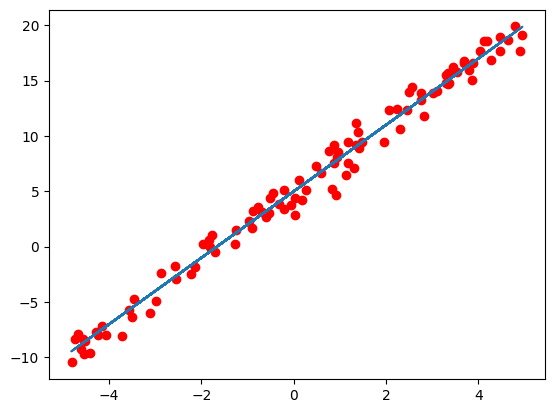

In [54]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(X, y, 'o', color='red')
plt.plot(X, 3*X+5)

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
mySVR = LinearSVM(eps=0.5)
mySVR.fit(X_train, y_train)

## Сравним с аналогичным классом из библиотеки sklearn

In [71]:
from sklearn.svm import SVR
SkLearn_svr = SVR(C=1.0, epsilon=0.5, tol=0.001, max_iter=10000, kernel='linear')
SkLearn_svr.fit(X_train, y_train)

SVR(epsilon=0.5, kernel='linear', max_iter=10000)

In [59]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def show_comparison(my_model, sklearn_model, types_of_comparing):
    print(types_of_comparing)
    my_model_prediction = my_model.predict(X_test)
    sklearn_model_prediction = sklearn_model.predict(X_test)
    print(f"MAE: My Model: {mean_absolute_error(y_test, my_model_prediction)} vs Sklearn: {mean_absolute_error(y_test, sklearn_model_prediction)}")
    print(f"RMSE: My Model: {root_mean_squared_error(y_test, my_model_prediction)} vs Sklearn: {root_mean_squared_error(y_test, sklearn_model_prediction)}")
    print(f"R-Squared: My Model: {r2_score(y_test, my_model_prediction)} vs Sklearn: {r2_score(y_test, sklearn_model_prediction)}")

In [72]:
show_comparison(mySVR, SkLearn_svr, "---Support Vectors Regressor Comparison---")

---Support Vectors Regressor Comparison---
MAE: My Model: 1.1883557460092495 vs Sklearn: 1.1265156000411758
RMSE: My Model: 1.3692375433250776 vs Sklearn: 1.3659107057231934
R-Squared: My Model: 0.9698576374167343 vs Sklearn: 0.9700039333199753


## Небольшие отклонения, но очень близко

## Сравним сами графики

In [73]:
print(f"My model: {mySVR.weights[0]} * x + {mySVR.bias[0]}")

My model: 3.027711616568424 * x + 4.61928088150509


In [74]:
print(f"Sklearn model: {SkLearn_svr.coef_[0][0]} * x + {SkLearn_svr.intercept_[0]}")

Sklearn model: 3.053055879082862 * x + 5.015165002098655


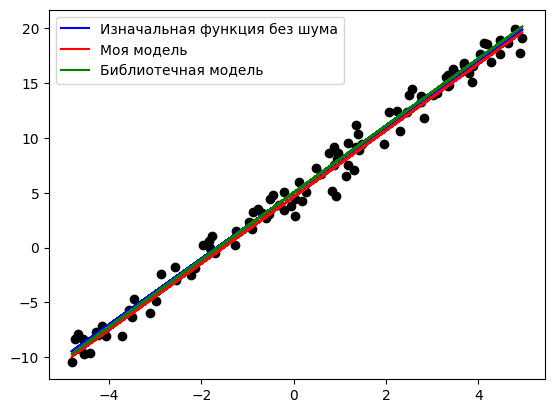

In [75]:
plt.plot(X, y, 'o', color='black')
plt.plot(X, 3*X+5, color='blue', label="Изначальная функция без шума")
plt.plot(X, mySVR.weights[0] * X + mySVR.bias, color='red', label="Моя модель")
plt.plot(X, SkLearn_svr.coef_[0] * X + SkLearn_svr.intercept_[0], color='green', label="Библиотечная модель")

plt.legend(loc='best')

plt.show()

## Мы использовали ϵ=0.5, давайте посмотрим на график с зазором

In [76]:
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]

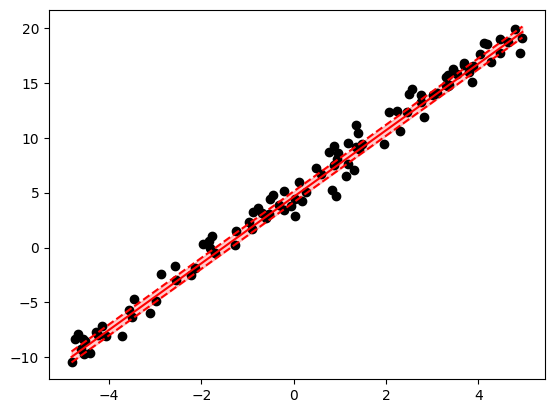

In [77]:
plt.plot(X, y, 'o', color='black')
plt.plot(X_sorted, mySVR.weights[0] * X_sorted + mySVR.bias + mySVR.eps, color='red', linestyle='dashed', linewidth=1.5)
plt.plot(X_sorted, mySVR.weights[0] * X_sorted + mySVR.bias, color='red')
plt.plot(X_sorted, mySVR.weights[0] * X_sorted + mySVR.bias - mySVR.eps,color='red', linestyle='--')

plt.fill_between(X_sorted.flatten(),
                 (mySVR.weights[0] * X_sorted + mySVR.bias - mySVR.eps).flatten(),
                 (mySVR.weights[0] * X_sorted + mySVR.bias + mySVR.eps).flatten(),
                 alpha=0.2, color='red')

plt.show()

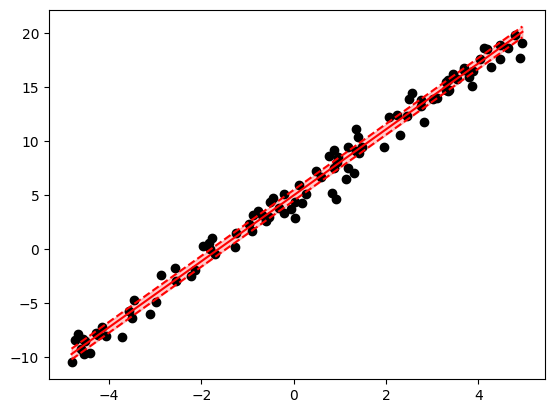

In [78]:
plt.plot(X, y, 'o', color='black')
plt.plot(X_sorted, SkLearn_svr.coef_[0] * X_sorted + SkLearn_svr.intercept_[0] + SkLearn_svr.epsilon, color='red', linestyle='dashed', linewidth=1.5)
plt.plot(X_sorted, SkLearn_svr.coef_[0] * X_sorted + SkLearn_svr.intercept_[0], color='red')
plt.plot(X_sorted, SkLearn_svr.coef_[0] * X_sorted + SkLearn_svr.intercept_[0] - SkLearn_svr.epsilon,color='red', linestyle='--')

plt.fill_between(X_sorted.flatten(),
                 (SkLearn_svr.coef_[0] * X_sorted + SkLearn_svr.intercept_[0] - SkLearn_svr.epsilon).flatten(),
                 (SkLearn_svr.coef_[0] * X_sorted + SkLearn_svr.intercept_[0] + SkLearn_svr.epsilon).flatten(),
                 alpha=0.2, color='red')

plt.show()

## За каждую точку за границей налагается штраф в зависимости от дальности от зазора и коэффициента C

## Ну, давайте ещё посмотрим на качество обучения модели

In [79]:
def plot_learning_curves(model, step_size=1):
    train_errors, test_errors = [], []
    for m in range(1, len(X_train), step_size):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_test_pred = model.predict(X_test)
        train_errors.append(root_mean_squared_error(y_train_pred, y_train[:m]))
        test_errors.append(root_mean_squared_error(y_test_pred, y_test))
    plt.plot(train_errors, "r--", linewidth=2, label="train")
    plt.plot(test_errors, "b-", linewidth=3, label="test")
    plt.legend(loc='best')

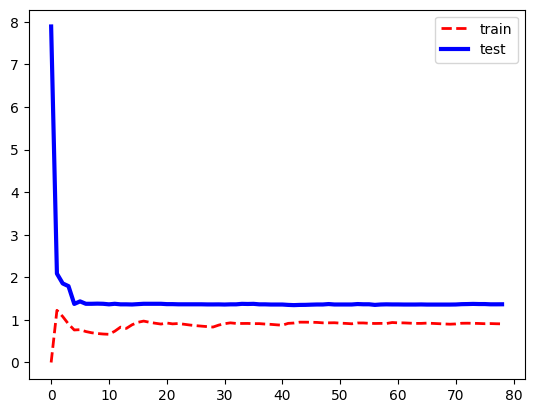

In [80]:
plot_learning_curves(SkLearn_svr)

## При малом количестве данных, очевидно, идет переобучение (линия строится так, чтобы, по сути, захватить точки), однако потом все же модель начинает находить баланс

## Давайте теперь рассмотрим еще один способ предсказания засчет различных функций, который активно применяет метод опорных векторов, а именно - ядерный трюк. Вообще говоря, хочется перейти на более сложную гиперплоскость (например, с двумерной плоскости на рехмерную) и пробовать использовать нашу модель там в надежде на улучшение результата. Засчет ядерного трюка мы можем избежать дорогостоящих операций перевода в большую размерность, найдя подходящую функцию ядра k(xn​, xm​), эквивалентную скалярному умножению в пространстве более высокого измерения. То есть в отличие от PolynomialFeatures мы находим некий эквивалент для перехода, но все вычисления делаем в исходном пространстве. Приведу следующие примеры ядер:

\begin{equation*}
\textbf{Линейное: } K(a, b) = a^T \cdot b \\
\textbf{Полиномиальное: } K(a, b) = (\gamma a^T \cdot b + r)^d \\
\textbf{Гауссово RBF: } K(a, b) = exp(-\gamma ||a-b||^2) \\
\textbf{Сигмоидальное: } K(a, b) = tanh(\gamma a^T \cdot b + r) \\
\end{equation*}

## К примеру, как и в случае с линейными моделями, создадим набор данных в виде кубической функции и попробуем предсказать, используя ядерный трюк

In [ ]:
X = np.random.uniform(-5, 5, 100)
X = X.reshape(-1, 1)
y = 3 * X**3 - 2*X**2 - 7*X + 1 + np.random.uniform(-10, 10, 100).reshape(-1,1)

In [ ]:
X_smooth = np.linspace(-5, 5, 500).reshape(-1, 1)
y_vals = 3*X_smooth*X_smooth*X_smooth - 2*X_smooth*X_smooth - 7*X_smooth + 1

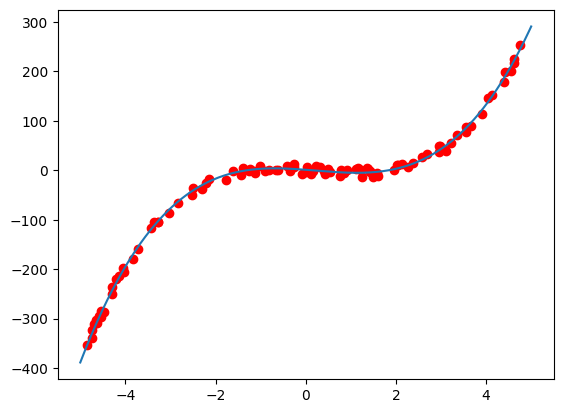

In [ ]:
plt.plot(X, y, 'o', color='red')
plt.plot(X_smooth, y_vals)

In [ ]:
SkLearn_svr = SVR(C=1.0, epsilon=0.5, kernel='poly', degree=3)
SkLearn_svr.fit(X_train, y_train)

SVR(epsilon=0.5, kernel='poly')

In [ ]:
y_pred = SkLearn_svr.predict(X_test)
print(f"MAE: {mean_absolute_error(y_pred, y_test)}, RMSE: {root_mean_squared_error(y_pred, y_test)}")

MAE: 0.5725532369600184, RMSE: 0.8056407928863691


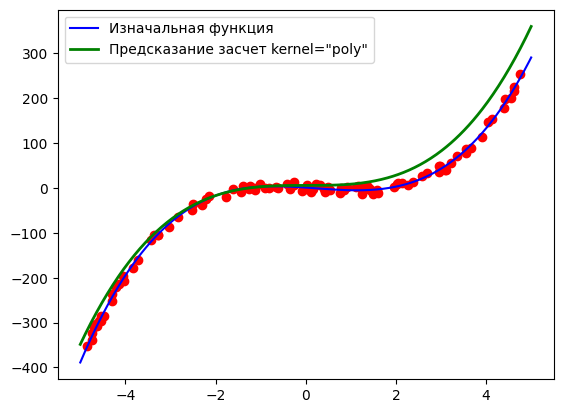

In [ ]:
plt.plot(X, y, 'o', color='red')
plt.plot(X_smooth, y_vals, color='blue', label='Изначальная функция')
plt.plot(X_smooth, SkLearn_svr.predict(X_smooth), color='green', linewidth=2, label='Предсказание засчет kernel="poly"')
plt.legend(loc='best')

## Вернемся к нашей задаче: предсказание предполагаемого результата за экзамен. Загрузим тренировочные и валидационные данные

In [ ]:
import pandas as pd

train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")

In [ ]:
X_train = train_df.drop('Exam_Score', axis=1)
X_valid = valid_df.drop('Exam_Score', axis=1)

y_train = train_df['Exam_Score']
y_valid= valid_df['Exam_Score']

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

\begin{equation*}
\textbf{Гауссово RBF: } K(a, b) = exp(-\gamma ||a-b||^2) \\
\end{equation*}

## Так как надо будет обучить слишком много, давайте вместо обычного GridSearch воспользуемся его случайной версией: разница лишь в том, что в случайной версии количество итераций ограничено и параметры выбираются случайно

In [ ]:
model = SVR()

rbf_params = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5]
}

grid_search = RandomizedSearchCV(model, rbf_params, cv=3, verbose=2, n_iter=150, random_state=42)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_rbf_model = grid_search.best_estimator_

Fitting 3 folds for each of 150 candidates, totalling 450 fits
[CV] END ........C=100, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   1.0s
[CV] END ........C=100, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   1.0s
[CV] END ........C=100, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   0.9s
[CV] END ...........C=100, epsilon=0.01, gamma=1, kernel=rbf; total time=   0.8s
[CV] END ...........C=100, epsilon=0.01, gamma=1, kernel=rbf; total time=   0.9s
[CV] END ...........C=100, epsilon=0.01, gamma=1, kernel=rbf; total time=   0.8s
[CV] END ..........C=10, epsilon=0.5, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ..........C=10, epsilon=0.5, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ..........C=10, epsilon=0.5, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ..........C=50, epsilon=0.2, gamma=auto, kernel=rbf; total time=   1.4s
[CV] END ..........C=50, epsilon=0.2, gamma=auto, kernel=rbf; total time=   1.4s
[CV] END ..........C=50, epsilon=0.2, gamma=au

\begin{equation*}
\textbf{Линейное ядро: } K(a, b) = a^T \cdot b \\
\end{equation*}

In [ ]:
linear_params = {
    'kernel': ['linear'],
    'C': [0.01, 0.1, 0.5, 1, 5, 10, 50],
    'epsilon': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
}

grid_search = RandomizedSearchCV(model, linear_params, cv=3, verbose=2, n_iter=150, random_state=42)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_linear_model = grid_search.best_estimator_

Fitting 3 folds for each of 42 candidates, totalling 126 fits
[CV] END ...............C=0.01, epsilon=0.001, kernel=linear; total time=   0.2s
[CV] END ...............C=0.01, epsilon=0.001, kernel=linear; total time=   0.2s
[CV] END ...............C=0.01, epsilon=0.001, kernel=linear; total time=   0.2s
[CV] END ................C=0.01, epsilon=0.01, kernel=linear; total time=   0.2s
[CV] END ................C=0.01, epsilon=0.01, kernel=linear; total time=   0.2s
[CV] END ................C=0.01, epsilon=0.01, kernel=linear; total time=   0.2s
[CV] END ................C=0.01, epsilon=0.05, kernel=linear; total time=   0.2s
[CV] END ................C=0.01, epsilon=0.05, kernel=linear; total time=   0.2s
[CV] END ................C=0.01, epsilon=0.05, kernel=linear; total time=   0.2s
[CV] END .................C=0.01, epsilon=0.1, kernel=linear; total time=   0.1s
[CV] END .................C=0.01, epsilon=0.1, kernel=linear; total time=   0.1s
[CV] END .................C=0.01, epsilon=0.1, 

\begin{equation*}
\textbf{Сигмоидальное ядро: } K(a, b) = tanh(\gamma a^T \cdot b + r) \\
\end{equation*}

In [ ]:
sigmoid_params = {
    'kernel': ['sigmoid'],
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'coef0': [0, 0.5, 1, 2],
    'epsilon': [0.01, 0.05, 0.1, 0.2]
}

grid_search = RandomizedSearchCV(model, sigmoid_params, cv=3, verbose=2, n_iter=150, random_state=42)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_sigmoid_model = grid_search.best_estimator_

Fitting 3 folds for each of 150 candidates, totalling 450 fits
[CV] END C=10, coef0=2, epsilon=0.01, gamma=0.1, kernel=sigmoid; total time=   0.5s
[CV] END C=10, coef0=2, epsilon=0.01, gamma=0.1, kernel=sigmoid; total time=   0.5s
[CV] END C=10, coef0=2, epsilon=0.01, gamma=0.1, kernel=sigmoid; total time=   0.5s
[CV] END C=10, coef0=1, epsilon=0.05, gamma=0.1, kernel=sigmoid; total time=   0.6s
[CV] END C=10, coef0=1, epsilon=0.05, gamma=0.1, kernel=sigmoid; total time=   0.5s
[CV] END C=10, coef0=1, epsilon=0.05, gamma=0.1, kernel=sigmoid; total time=   0.5s
[CV] END C=50, coef0=1, epsilon=0.2, gamma=auto, kernel=sigmoid; total time=   0.5s
[CV] END C=50, coef0=1, epsilon=0.2, gamma=auto, kernel=sigmoid; total time=   0.5s
[CV] END C=50, coef0=1, epsilon=0.2, gamma=auto, kernel=sigmoid; total time=   0.5s
[CV] END C=50, coef0=0.5, epsilon=0.2, gamma=0.001, kernel=sigmoid; total time=   0.2s
[CV] END C=50, coef0=0.5, epsilon=0.2, gamma=0.001, kernel=sigmoid; total time=   0.3s
[CV] EN

## Рассмотрим точность моделей на валидационных данных

In [ ]:
def show_scores(model, model_name):
    y_pred = model.predict(X_valid)
    print(f"Scoring of {model_name} Model")
    print(f"RMSE: {root_mean_squared_error(y_valid, y_pred)}")
    print(f"MAE: {mean_absolute_error(y_valid, y_pred)}")
    print(f"R2: {r2_score(y_valid, y_pred)}\n")

In [ ]:
show_scores(best_rbf_model, "RBF kernel")
show_scores(best_linear_model, "Linear Kernel")
show_scores(best_sigmoid_model, "Sigmoid Kernel")

Scoring of RBF kernel Model
RMSE: 2.272955201832289
MAE: 0.4698619540586514
R2: 0.673117072788695

Scoring of Linear Kernel Model
RMSE: 2.272759179446059
MAE: 0.4696664653713566
R2: 0.6731734519098906

Scoring of Sigmoid Kernel Model
RMSE: 2.3196545406861215
MAE: 0.601885486840824
R2: 0.6595470442559885



## Рассмотрим обучаемость наших моделей

In [ ]:
def plot_learning_curves(model, step_size=10):
    train_errors, valid_errors = [], []
    for m in range(1, len(X_train), step_size):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_valid_pred = model.predict(X_valid)
        train_errors.append(root_mean_squared_error(y_train_pred, y_train[:m]))
        valid_errors.append(root_mean_squared_error(y_valid_pred, y_valid))
    plt.plot(train_errors, "r--", linewidth=2, label="train")
    plt.plot(valid_errors, "b-", linewidth=3, label="valid")
    plt.legend(loc='best')

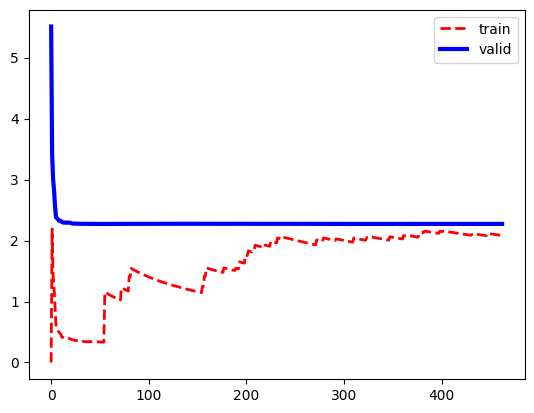

In [ ]:
plot_learning_curves(best_rbf_model)

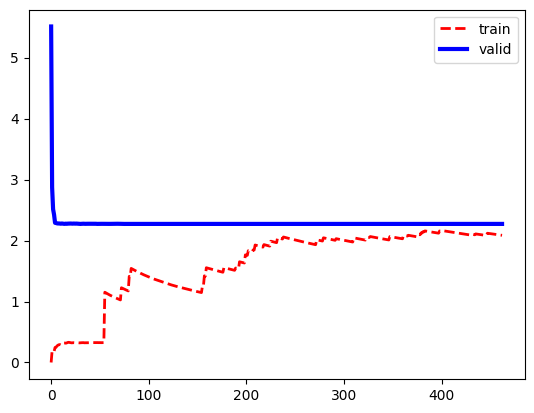

In [ ]:
plot_learning_curves(best_linear_model)

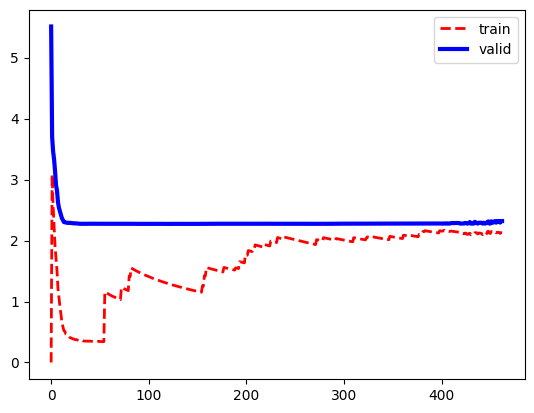

In [ ]:
plot_learning_curves(best_sigmoid_model)

## И графики отклонений

In [ ]:
def vizual_pred_test(y_test, y_pred, title):
    plt.figure(figsize=(10, 10))

    plt.scatter(y_test, y_pred, alpha=0.3, s=10, c='blue', label='Предсказания')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y = x')

    plt.xlabel('Тестовые данные', fontsize=12)
    plt.ylabel('Предсказанные точки', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

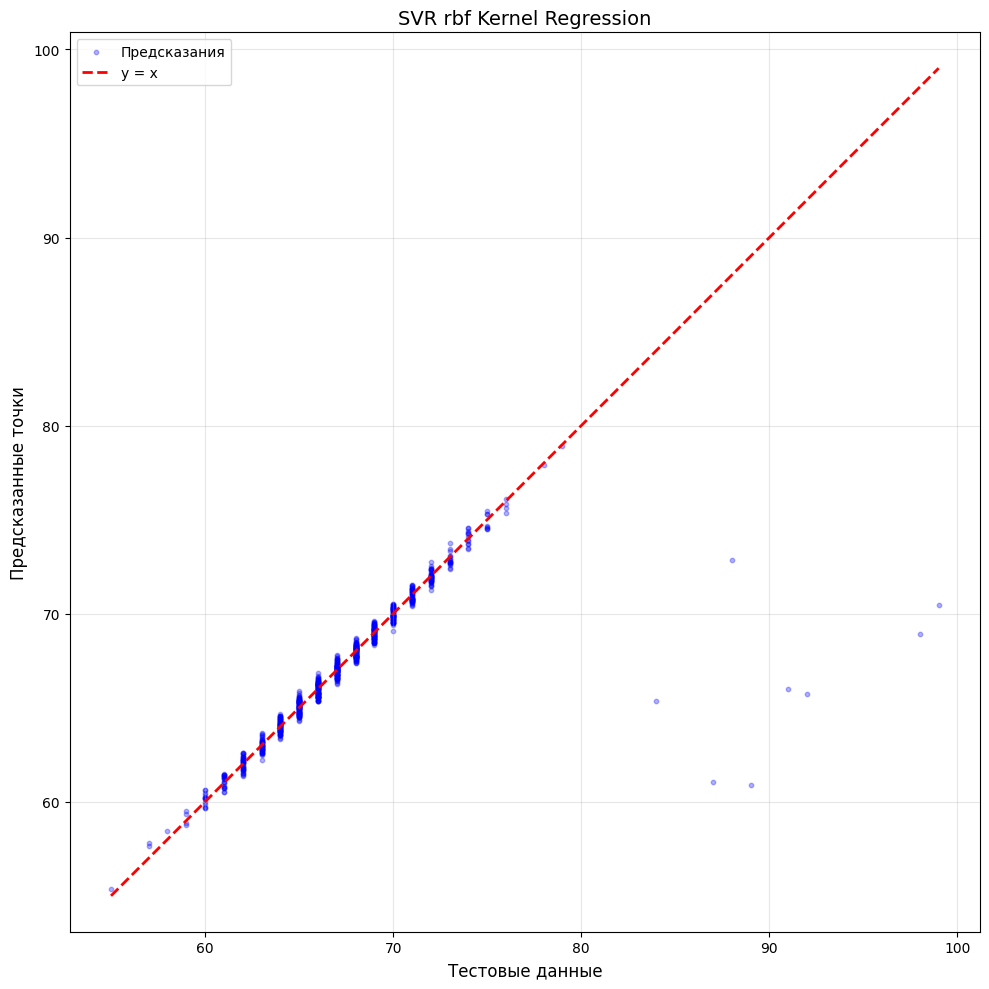

In [ ]:
vizual_pred_test(y_valid, best_rbf_model.predict(X_valid), "SVR rbf Kernel Regression")

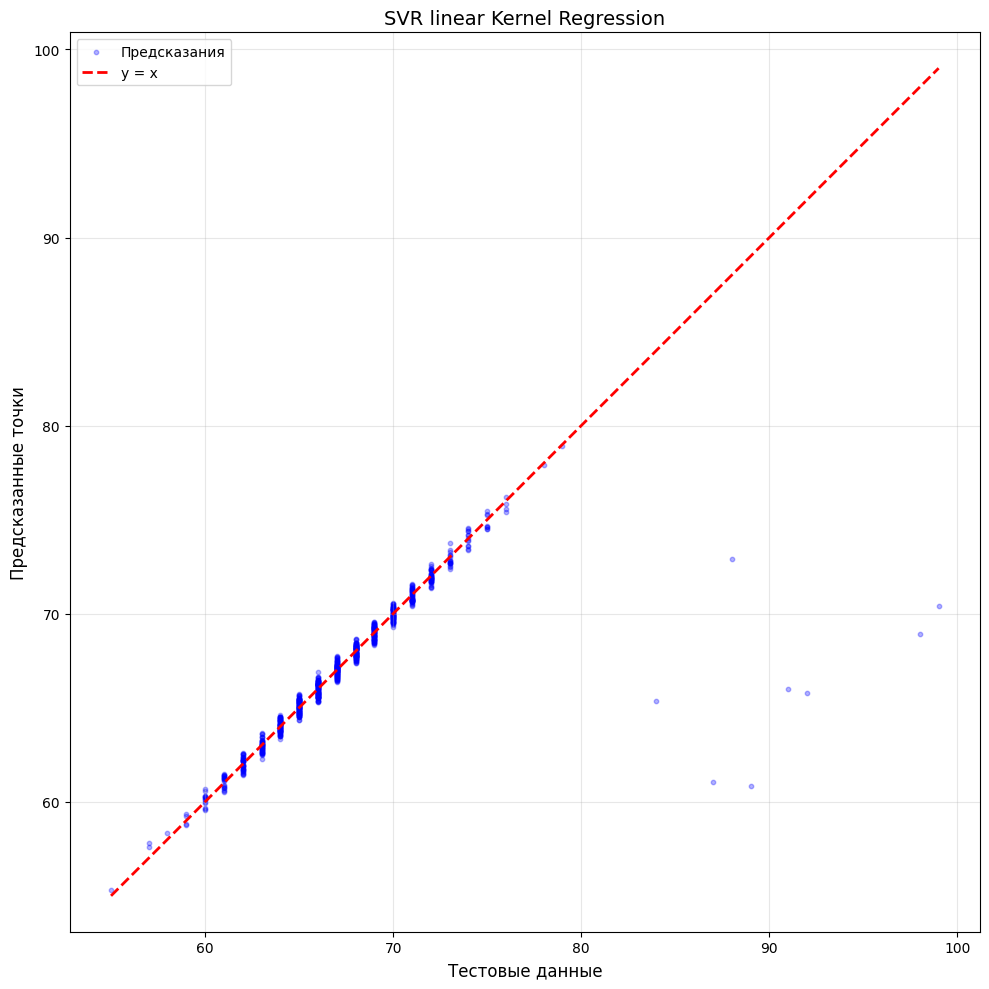

In [ ]:
vizual_pred_test(y_valid, best_linear_model.predict(X_valid), "SVR linear Kernel Regression")

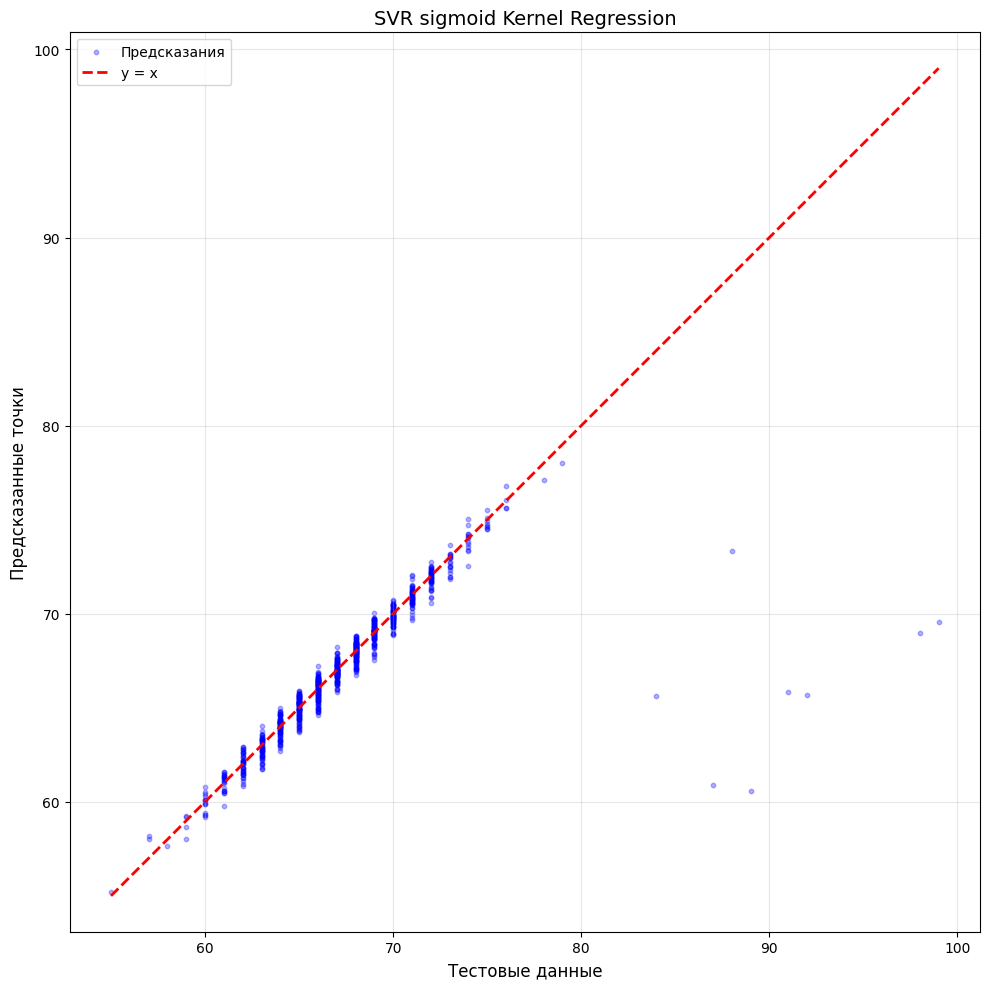

In [ ]:
vizual_pred_test(y_valid, best_sigmoid_model.predict(X_valid), "SVR sigmoid Kernel Regression")

## Давайте сохраним эти результаты

In [ ]:
results_svm= pd.DataFrame(columns=['model', 'params', 'MAE', 'RMSE', 'R2'])

In [ ]:
def resulting(model, df, model_name):
    prediction = model.predict(df)
    row = {'model': model_name,
                  'params': model.get_params(),
                  'MAE': mean_absolute_error(y_valid, prediction),
                  'RMSE': root_mean_squared_error(y_valid, prediction),
                  'R2': r2_score(y_valid, prediction)}
    results_svm.loc[len(results_svm)] = row

In [ ]:
resulting(best_rbf_model, X_valid, "SVR RBF kernel")
resulting(best_linear_model, X_valid, "SVR Linear Kernel")
resulting(best_sigmoid_model, X_valid, "SVR Sigmoid Kernel")

In [ ]:
results_svm

,model,params,MAE,RMSE,R2
0,SVR RBF kernel,"{'C': 50, 'cache_size': 200, 'coef0': 0.0, 'de...",0.469776,2.272834,0.673152
1,SVR Linear Kernel,"{'C': 0.5, 'cache_size': 200, 'coef0': 0.0, 'd...",0.469638,2.272748,0.673177
2,SVR Sigmoid Kernel,"{'C': 50, 'cache_size': 200, 'coef0': 0.5, 'de...",0.601261,2.319489,0.659596


In [ ]:
results_svm.to_csv("data/results_svm.csv")